[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


'all-data.csv' already exists. Skipping upload.
Dataset Loaded Successfully!

First 5 Rows:
  sentiment                                               text
0   neutral  According to Gran , the company has no plans t...
1   neutral  Technopolis plans to develop in stages an area...
2  negative  The international electronic industry company ...
3  positive  With the new production plant the company woul...
4  positive  According to the company 's updated strategy f...

Dataset Shape:
(4846, 2)

========== DATA INFORMATION ==========

Missing Values:
sentiment    0
text         0
dtype: int64

Duplicate Rows:
6

Sentiment Distribution:
sentiment
neutral     2879
positive    1363
negative     604
Name: count, dtype: int64

Shape After Cleaning:
(4840, 2)

Sentiment Classes:
['neutral' 'negative' 'positive']

Text preprocessing completed!


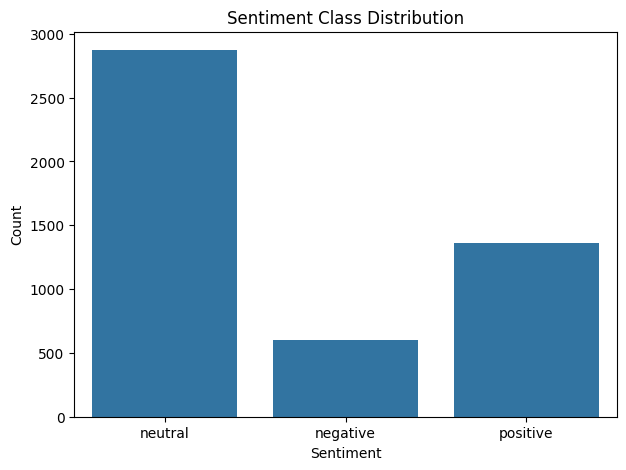


TF-IDF Matrix Shape:
(4840, 5000)

Training Samples: 3872
Testing Samples: 968

NAIVE BAYES RESULTS
Accuracy : 0.7024793388429752
Precision: 0.709170656059543
Recall   : 0.7024793388429752
F1 Score : 0.6614123582702959

Classification Report:
              precision    recall  f1-score   support

    negative       0.87      0.21      0.34       121
     neutral       0.71      0.96      0.81       575
    positive       0.64      0.38      0.48       272

    accuracy                           0.70       968
   macro avg       0.74      0.52      0.55       968
weighted avg       0.71      0.70      0.66       968


LOGISTIC REGRESSION RESULTS
Accuracy : 0.7303719008264463
Precision: 0.7346205572882946
Recall   : 0.7303719008264463
F1 Score : 0.7047256838886972

Classification Report:
              precision    recall  f1-score   support

    negative       0.81      0.36      0.49       121
     neutral       0.73      0.94      0.82       575
    positive       0.71      0.45      

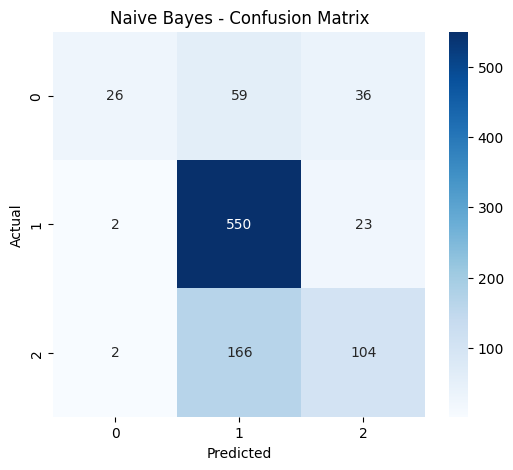

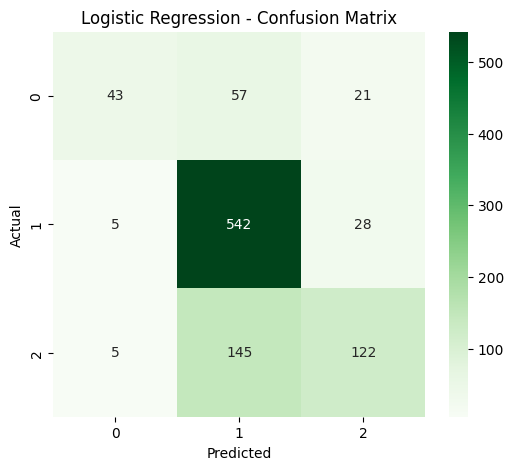

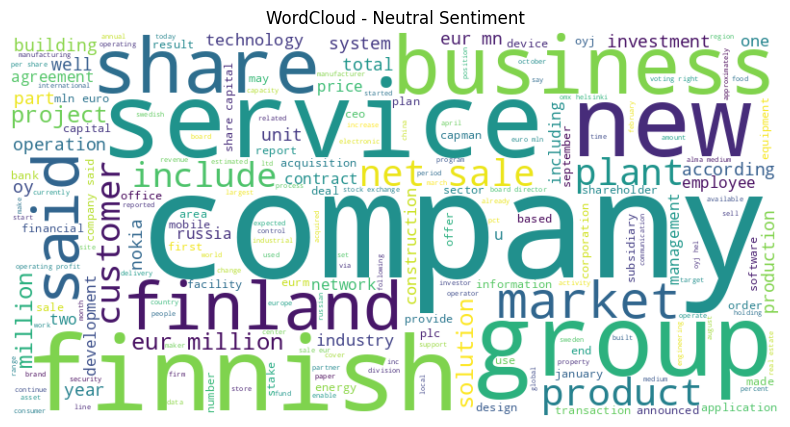

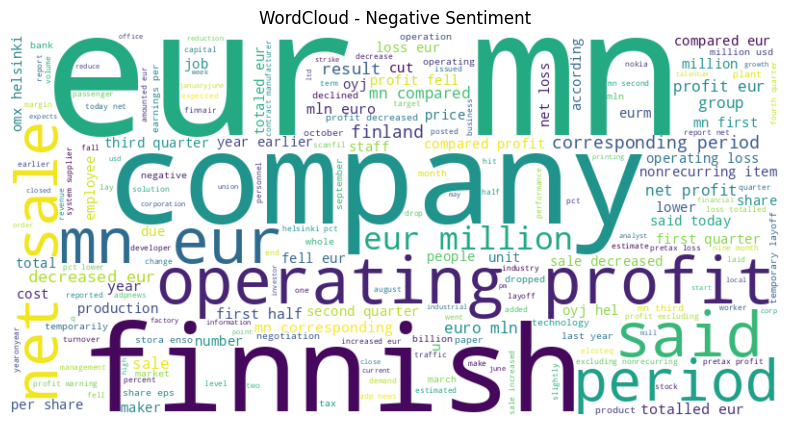

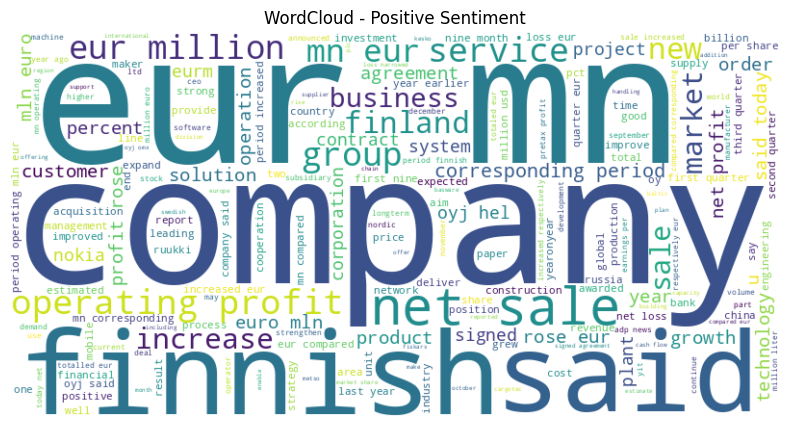


MISCLASSIFIED EXAMPLES
                                                                                                                                                                                                                                                Text   Actual Predicted
     ( ADP News ) - Nov 3 , 2008 - Finnish cargo handling systems and services company Cargotec Oyj ( OMX : CGCBV ) said today that it acquired 80 % stakes in Italian service companies CVS Technoports Srl and CVS Service Srl from Italian handli positive   neutral
                                                                                                                                    It is profitable to make pulp , paper , and sawn goods in areas where the combination of these factors is good .  neutral  positive
Finnish consulting and engineering group Poyry Plc ( OMX Helsinki : POY ) said on Wednesday ( 1 October ) that it has been awarded a contract by Tanqia Dibba FZC as owner-engineer for 

In [10]:
# ============================================
# TASK 4 - SENTIMENT ANALYSIS
# Oasis Infobyte Data Analytics Internship
# ============================================

# ================================
# 1. IMPORT LIBRARIES
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import os

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud

# Download NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


# ================================
# 2. UPLOAD DATASET
# ================================

# 👇 DATASET NAME
# If your file name is different, change only this line

file_name = "all-data.csv"

# Check if file exists, if not, prompt for upload
if not os.path.exists(file_name):
    print("File not found, please upload 'all-data.csv'")
    uploaded = files.upload()
    if file_name not in uploaded:
        raise FileNotFoundError(f"{file_name} was not uploaded. Please upload the correct file.")
else:
    print(f"'{file_name}' already exists. Skipping upload.")

# ================================
# LOAD DATASET
# ================================

df = pd.read_csv(
    file_name,
    encoding="latin-1",
    header=None,
    names=["sentiment", "text"]
)

print("Dataset Loaded Successfully!")

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)


# ================================
# 3. DATA INSPECTION
# ================================

print("\n========== DATA INFORMATION ==========")

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nSentiment Distribution:")
print(df["sentiment"].value_counts())


# ================================
# 4. REMOVE MISSING VALUES
# ================================

df.dropna(subset=["text", "sentiment"], inplace=True)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

print("\nShape After Cleaning:")
print(df.shape)


# ================================
# 5. SENTIMENT STANDARDIZATION
# ================================

df["sentiment"] = df["sentiment"].str.lower().str.strip()

print("\nSentiment Classes:")
print(df["sentiment"].unique())


# ================================
# 6. TEXT PREPROCESSING
# ================================

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def clean_text(text):

    text = str(text)

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Tokenization
    words = text.split()

    # Remove stopwords
    words = [
        word for word in words
        if word not in stop_words
    ]

    # Lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]

    return " ".join(words)


df["clean_text"] = df["text"].apply(clean_text)


print("\nText preprocessing completed!")


# ================================
# 7. CLASS DISTRIBUTION
# ================================

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="sentiment"
)

plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()


# ================================
# 8. TF-IDF VECTORIZATION
# ================================

# TF-IDF converts text into numerical features.
# It gives higher importance to words that are
# useful for distinguishing documents.

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X = tfidf.fit_transform(df["clean_text"])

y = df["sentiment"]


print("\nTF-IDF Matrix Shape:")
print(X.shape)


# ================================
# 9. TRAIN / TEST SPLIT
# ================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])


# =================================================
# 10. MODEL 1 - NAIVE BAYES
# =================================================

nb_model = MultinomialNB()

nb_model.fit(
    X_train,
    y_train
)

nb_predictions = nb_model.predict(X_test)


# ================================
# 11. NAIVE BAYES EVALUATION
# ================================

nb_accuracy = accuracy_score(
    y_test,
    nb_predictions
)

nb_precision = precision_score(
    y_test,
    nb_predictions,
    average="weighted",
    zero_division=0
)

nb_recall = recall_score(
    y_test,
    nb_predictions,
    average="weighted",
    zero_division=0
)

nb_f1 = f1_score(
    y_test,
    nb_predictions,
    average="weighted",
    zero_division=0
)

print("\n================================")
print("NAIVE BAYES RESULTS")
print("================================")

print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1 Score :", nb_f1)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        nb_predictions,
        zero_division=0
    )
)


# =================================================
# 12. MODEL 2 - LOGISTIC REGRESSION
# =================================================

lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(
    X_train,
    y_train
)

lr_predictions = lr_model.predict(X_test)


# ================================
# 13. LOGISTIC REGRESSION EVALUATION
# ================================

lr_accuracy = accuracy_score(
    y_test,
    lr_predictions
)

lr_precision = precision_score(
    y_test,
    lr_predictions,
    average="weighted",
    zero_division=0
)

lr_recall = recall_score(
    y_test,
    lr_predictions,
    average="weighted",
    zero_division=0
)

lr_f1 = f1_score(
    y_test,
    lr_predictions,
    average="weighted",
    zero_division=0
)

print("\n================================")
print("LOGISTIC REGRESSION RESULTS")
print("================================")

print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        lr_predictions,
        zero_division=0
    )
)


# ================================
# 14. MODEL COMPARISON
# ================================

results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression"
    ],

    "Accuracy": [
        nb_accuracy,
        lr_accuracy
    ],

    "Precision": [
        nb_precision,
        lr_precision
    ],

    "Recall": [
        nb_recall,
        lr_recall
    ],

    "F1 Score": [
        nb_f1,
        lr_f1
    ]
})

print("\n================================")
print("MODEL COMPARISON")
print("================================")

print(results)


# ================================
# 15. CONFUSION MATRIX
# NAIVE BAYES
# ================================

plt.figure(figsize=(6,5))

nb_cm = confusion_matrix(
    y_test,
    nb_predictions
)

sns.heatmap(
    nb_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Naive Bayes - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


# ================================
# 16. CONFUSION MATRIX
# LOGISTIC REGRESSION
# ================================

plt.figure(figsize=(6,5))

lr_cm = confusion_matrix(
    y_test,
    lr_predictions
)

sns.heatmap(
    lr_cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


# ================================
# 17. WORDCLOUD
# ================================

sentiments = df["sentiment"].unique()

for sentiment in sentiments:

    text_data = " ".join(
        df[
            df["sentiment"] == sentiment
        ]["clean_text"]
    )

    if len(text_data.strip()) == 0:
        continue

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate(text_data)

    plt.figure(figsize=(10,5))

    plt.imshow(
        wordcloud,
        interpolation="bilinear"
    )

    plt.axis("off")

    plt.title(
        f"WordCloud - {sentiment.capitalize()} Sentiment"
    )

    plt.show()


# ================================
# 18. ERROR ANALYSIS
# ================================

error_df = pd.DataFrame({
    "Text": df.loc[y_test.index, "text"],
    "Actual": y_test,
    "Predicted": lr_predictions
})

misclassified = error_df[
    error_df["Actual"] != error_df["Predicted"]
]

print("\n================================")
print("MISCLASSIFIED EXAMPLES")
print("================================")

print(
    misclassified.head(5).to_string(
        index=False
    )
)


# ================================
# 19. BEST MODEL
# ================================

if lr_f1 > nb_f1:

    best_model = "Logistic Regression"
    best_score = lr_f1

else:

    best_model = "Naive Bayes"
    best_score = nb_f1


print("\n================================")
print("FINAL CONCLUSION")
print("================================")

print(
    "Best Model:",
    best_model
)

print(
    "Best F1 Score:",
    best_score
)

print(
    "\nTask 4 - Sentiment Analysis Completed Successfully!"
)
